# **Exercise - Building a Fully Connected Network (FCN) for Devnagari Digit Classification.**

 **Task 1 - Data Preparation**

***os.listdir(folder)*** - lists all files/sub-folders inside the given folder.

***sorted()*** - arranges them alphabetically so the label mapping is always consistent (e.g. digit_0 always maps to 0).

***class_map = {name: i for i, name in enumerate(class_names)}*** - Creates a dictionary mapping each folder name to a number, for example {"digit_0": 0, "digit_1": 1, ..., "digit_9": 9}.

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


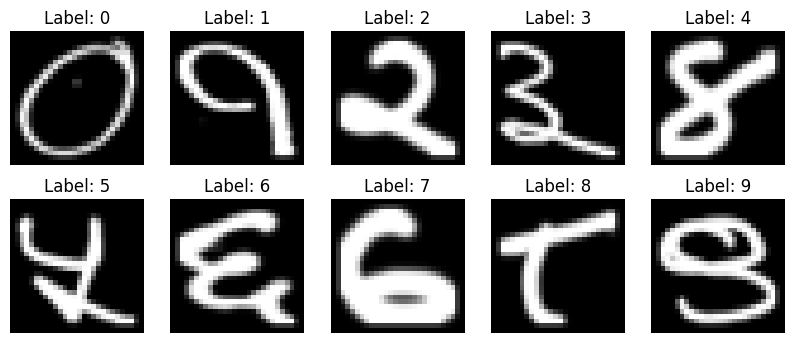

In [15]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/SEM6_AI/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/SEM6_AI/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
    class_path = os.path.join(folder, class_name) # Builds the full path to the class sub-folder, e.g. "dataset/Train/digit_0".
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# Shuffle the images
indices = np.random.permutation(len(x_train))
x_train = x_train[indices]
y_train = y_train[indices]

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for digit in range(10):
    # Find first image with this label
    idx = np.argmax(y_train[:, digit] == 1)
    plt.subplot(2, 5, digit + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {digit}")
    plt.axis("off")
plt.show()

**Task 2 - Build the FCN Model**

In [16]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
  [
  keras.layers.Input(shape=input_shape),
  keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
  keras.layers.Dense(64, activation="sigmoid"),
  keras.layers.Dense(128, activation="sigmoid"),
  keras.layers.Dense(256, activation="sigmoid"),
  keras.layers.Dense(num_classes, activation="softmax"),
  ]
)

**Task 3 - Complie the Model**

In [17]:
model.compile(
  optimizer="adam",
  loss="categorical_crossentropy", # Loss function for multi-class classification
  metrics=["accuracy"] # Track accuracy during training
)

**Task 4 - Train the Model**

In [18]:
batch_size = 128
epochs = 20

# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"), #saves the model after every epoch
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ), #watches the validation loss after every epoch. If the validation loss doesn't improve for 4 consecutive epochs, stop training
]

# Train the model with callbacks and validation split
history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.2,
  callbacks=callbacks,
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4316 - loss: 1.8556 - val_accuracy: 0.7747 - val_loss: 1.0271
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8338 - loss: 0.6366 - val_accuracy: 0.8753 - val_loss: 0.4283
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8991 - loss: 0.3359 - val_accuracy: 0.9224 - val_loss: 0.2822
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9359 - loss: 0.2305 - val_accuracy: 0.9403 - val_loss: 0.2069
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9514 - loss: 0.1748 - val_accuracy: 0.9497 - val_loss: 0.1725
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9596 - loss: 0.1403 - val_accuracy: 0.9582 - val_loss: 0.1508
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9671 - loss: 0.1172 - val_accuracy: 0.9638 - val_loss: 0.1312
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9738 - loss: 0.0971 - val_accuracy: 0

**For Epoch 1:**

107/107 -> all 107 batches processed

2s -> epoch took  4seconds

19m/s -> each batch took 17 milliseconds

accuracy (0.4316) -> model got 43.16% correct on TRAINING data

loss (1.8556) -> training loss is high but gets decreased gradually

val_accuracy (0.7747) -> model got 77.47% correct on VALIDATION data

val_loss (1.0271) -> validation loss is high but gets decreased as epoch increases

**Task 5 - Evaluate the Model**

In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded Model Results:")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f} %")

94/94 - 0s - 2ms/step - accuracy: 0.9760 - loss: 0.0806

Loaded Model Results:
Test Loss     : 0.0806
Test accuracy: 97.60 %


**Task 6 - Save and Load the Model**

In [20]:
# Save the trained model
model.save("devnagari_fcn_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [21]:
# Load the saved model
loaded_model = tf.keras.models.load_model("devnagari_fcn_model.h5")
print("Model loaded successfully!")

Model loaded successfully!


In [22]:
# Re-evaluate the loaded model on test set
test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"\nLoaded Model Results:")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f} %")

94/94 - 1s - 12ms/step - accuracy: 0.9760 - loss: 0.0806

Loaded Model Results:
Test Loss     : 0.0806
Test Accuracy : 97.60 %


**Task 7 - Predictions**

In [25]:
# Predict on test data
predictions = model.predict(x_test)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Predicted label for first image: 0
True label for first image: 0
